import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
url_product = "https://fakestoreapi.com/products"
response = requests.get(url_product)
data = response.json()

In [12]:
product_pd = pd.DataFrame(data)
product_pd.head(5)

,id,title,price,description,category,image,rating
0,1,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",109.95,Your perfect pack for everyday use and walks i...,men's clothing,https://fakestoreapi.com/img/81fPKd-2AYL._AC_S...,"{'rate': 3.9, 'count': 120}"
1,2,Mens Casual Premium Slim Fit T-Shirts,22.30,"Slim-fitting style, contrast raglan long sleev...",men's clothing,https://fakestoreapi.com/img/71-3HjGNDUL._AC_S...,"{'rate': 4.1, 'count': 259}"
2,3,Mens Cotton Jacket,55.99,great outerwear jackets for Spring/Autumn/Wint...,men's clothing,https://fakestoreapi.com/img/71li-ujtlUL._AC_U...,"{'rate': 4.7, 'count': 500}"
3,4,Mens Casual Slim Fit,15.99,The color could be slightly different between ...,men's clothing,https://fakestoreapi.com/img/71YXzeOuslL._AC_U...,"{'rate': 2.1, 'count': 430}"
4,5,John Hardy Women's Legends Naga Gold & Silver ...,695.00,"From our Legends Collection, the Naga was insp...",jewelery,https://fakestoreapi.com/img/71pWzhdJNwL._AC_U...,"{'rate': 4.6, 'count': 400}"


In [13]:
analysis_table = product_pd[["id", "title", "price", "category"]]
analysis_table.head(5)

,id,title,price,category
0,1,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",109.95,men's clothing
1,2,Mens Casual Premium Slim Fit T-Shirts,22.30,men's clothing
2,3,Mens Cotton Jacket,55.99,men's clothing
3,4,Mens Casual Slim Fit,15.99,men's clothing
4,5,John Hardy Women's Legends Naga Gold & Silver ...,695.00,jewelery


In [15]:
media_category = analysis_table.groupby("category")["price"].mean()
media_category

category
electronics         332.498333
jewelery            220.995000
men's clothing       51.057500
women's clothing     26.286667
Name: price, dtype: float64

In [17]:
clothing_category = analysis_table[analysis_table["title"].str.contains("jacket",case=False)]
clothing_category

,id,title,price,category
2,3,Mens Cotton Jacket,55.99,men's clothing
14,15,BIYLACLESEN Women's 3-in-1 Snowboard Jacket Wi...,56.99,women's clothing
15,16,Lock and Love Women's Removable Hooded Faux Le...,29.95,women's clothing
16,17,Rain Jacket Women Windbreaker Striped Climbing...,39.99,women's clothing


In [20]:
media_clothing_category = clothing_category["price"].mean().round(2)
media_clothing_category

np.float64(45.73)

<function matplotlib.pyplot.show(close=None, block=None)>

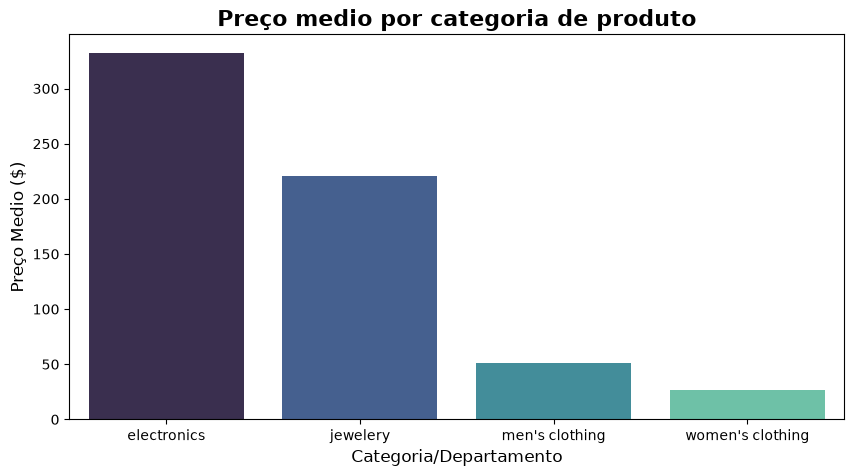

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(x=media_category.index, y=media_category.values,hue=media_category.index, palette="mako")
plt.title("Preço medio por categoria de produto", fontsize=16, fontweight="bold")
plt.xlabel("Categoria/Departamento", fontsize=12)
plt.ylabel("Preço Medio ($)", fontsize=12)
plt.show